In [1]:
import json
from pathlib import Path
from folde.types import ModelEvaluation
from folde.util import convert_compaign_result_collection_to_df

# EVAL_PREFIX = '250518_simple_ablation'
EVAL_PREFIX = '250522-holdup'
# OTHER_EVAL_PREFIXES = ['250518_simple_ablation']
OTHER_EVAL_PREFIXES = []
CHECKPOINT_DIR = 'notebooks/jacob/model_evals/'


def load_model_eval(checkpoint_dir, eval_prefix: str, other_eval_prefixes: list[str] = []) -> ModelEvaluation:
    result_list = []
    for json_path in Path(checkpoint_dir).glob(f'{eval_prefix}*'):
        with open(json_path, 'r') as f:
            result_list.append(ModelEvaluation(**json.load(f)))

    for other_eval_prefix in other_eval_prefixes:
        for json_path in Path(checkpoint_dir).glob(f'{other_eval_prefix}*'):
            with open(json_path, 'r') as f:
                result_list.append(ModelEvaluation(**json.load(f)))
    if len(result_list) == 0:
        raise ValueError(f'Failed to find any matching files.')
    
    all_dms_ids = set()
    for result in result_list:
        for campaign_result in result.campaign_results:
            all_dms_ids.add(campaign_result.dms_id)
    print(f'Loading results for DMSs: {all_dms_ids}')
    
    composite_result = None
    for single_result in result_list:
        single_result_dms_list = [cr.dms_id for cr in single_result.campaign_results]
        single_result_has_all_dms = all(dms_id in single_result_dms_list for dms_id in all_dms_ids)
        if not single_result_has_all_dms:
            print(f'Skipping {single_result.name} because it is missing some DMS IDs.')
            continue

        if composite_result is None:
            composite_result = single_result
            continue

        # Insert all campaign results into the appropriate list.
        for single_campaign_result in single_result.campaign_results:
            for composite_campaign_result in composite_result.campaign_results:
                if single_campaign_result.dms_id == composite_campaign_result.dms_id:
                    composite_campaign_result.config_results.extend(single_campaign_result.config_results)
                    break
            else:
                raise ValueError(f'This should not have happened. We started with one of the results that had all DMSs. But one of the following results had a new DMS id: {single_campaign_result.dms_id}')
    
    return composite_result

results = load_model_eval(CHECKPOINT_DIR, EVAL_PREFIX, OTHER_EVAL_PREFIXES)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)

Loading results for DMSs: {'OXDA_RHOTO_Vanella_2023_activity', 'BLAT_ECOLX_Firnberg_2014', 'CBS_HUMAN_Sun_2020', 'SHOC2_HUMAN_Kwon_2022', 'ANCSZ_Hobbs_2022', 'PPM1D_HUMAN_Miller_2022', 'HXK4_HUMAN_Gersing_2022_activity', 'HEM3_HUMAN_Loggerenberg_2023', 'HSP82_YEAST_Flynn_2019'}


/var/tmp/ipykernel_1216940/1457593279.py:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/var/tmp/ipykernel_1216940/1457593279.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/var/tmp/ipykernel_1216940/1457593279.py:101: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/var/tmp/ipykernel_1216940/1457593279.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/var/tmp/ipykernel_1216940/1457593279.py:101: FutureWarning: 

Setting a gradient pale

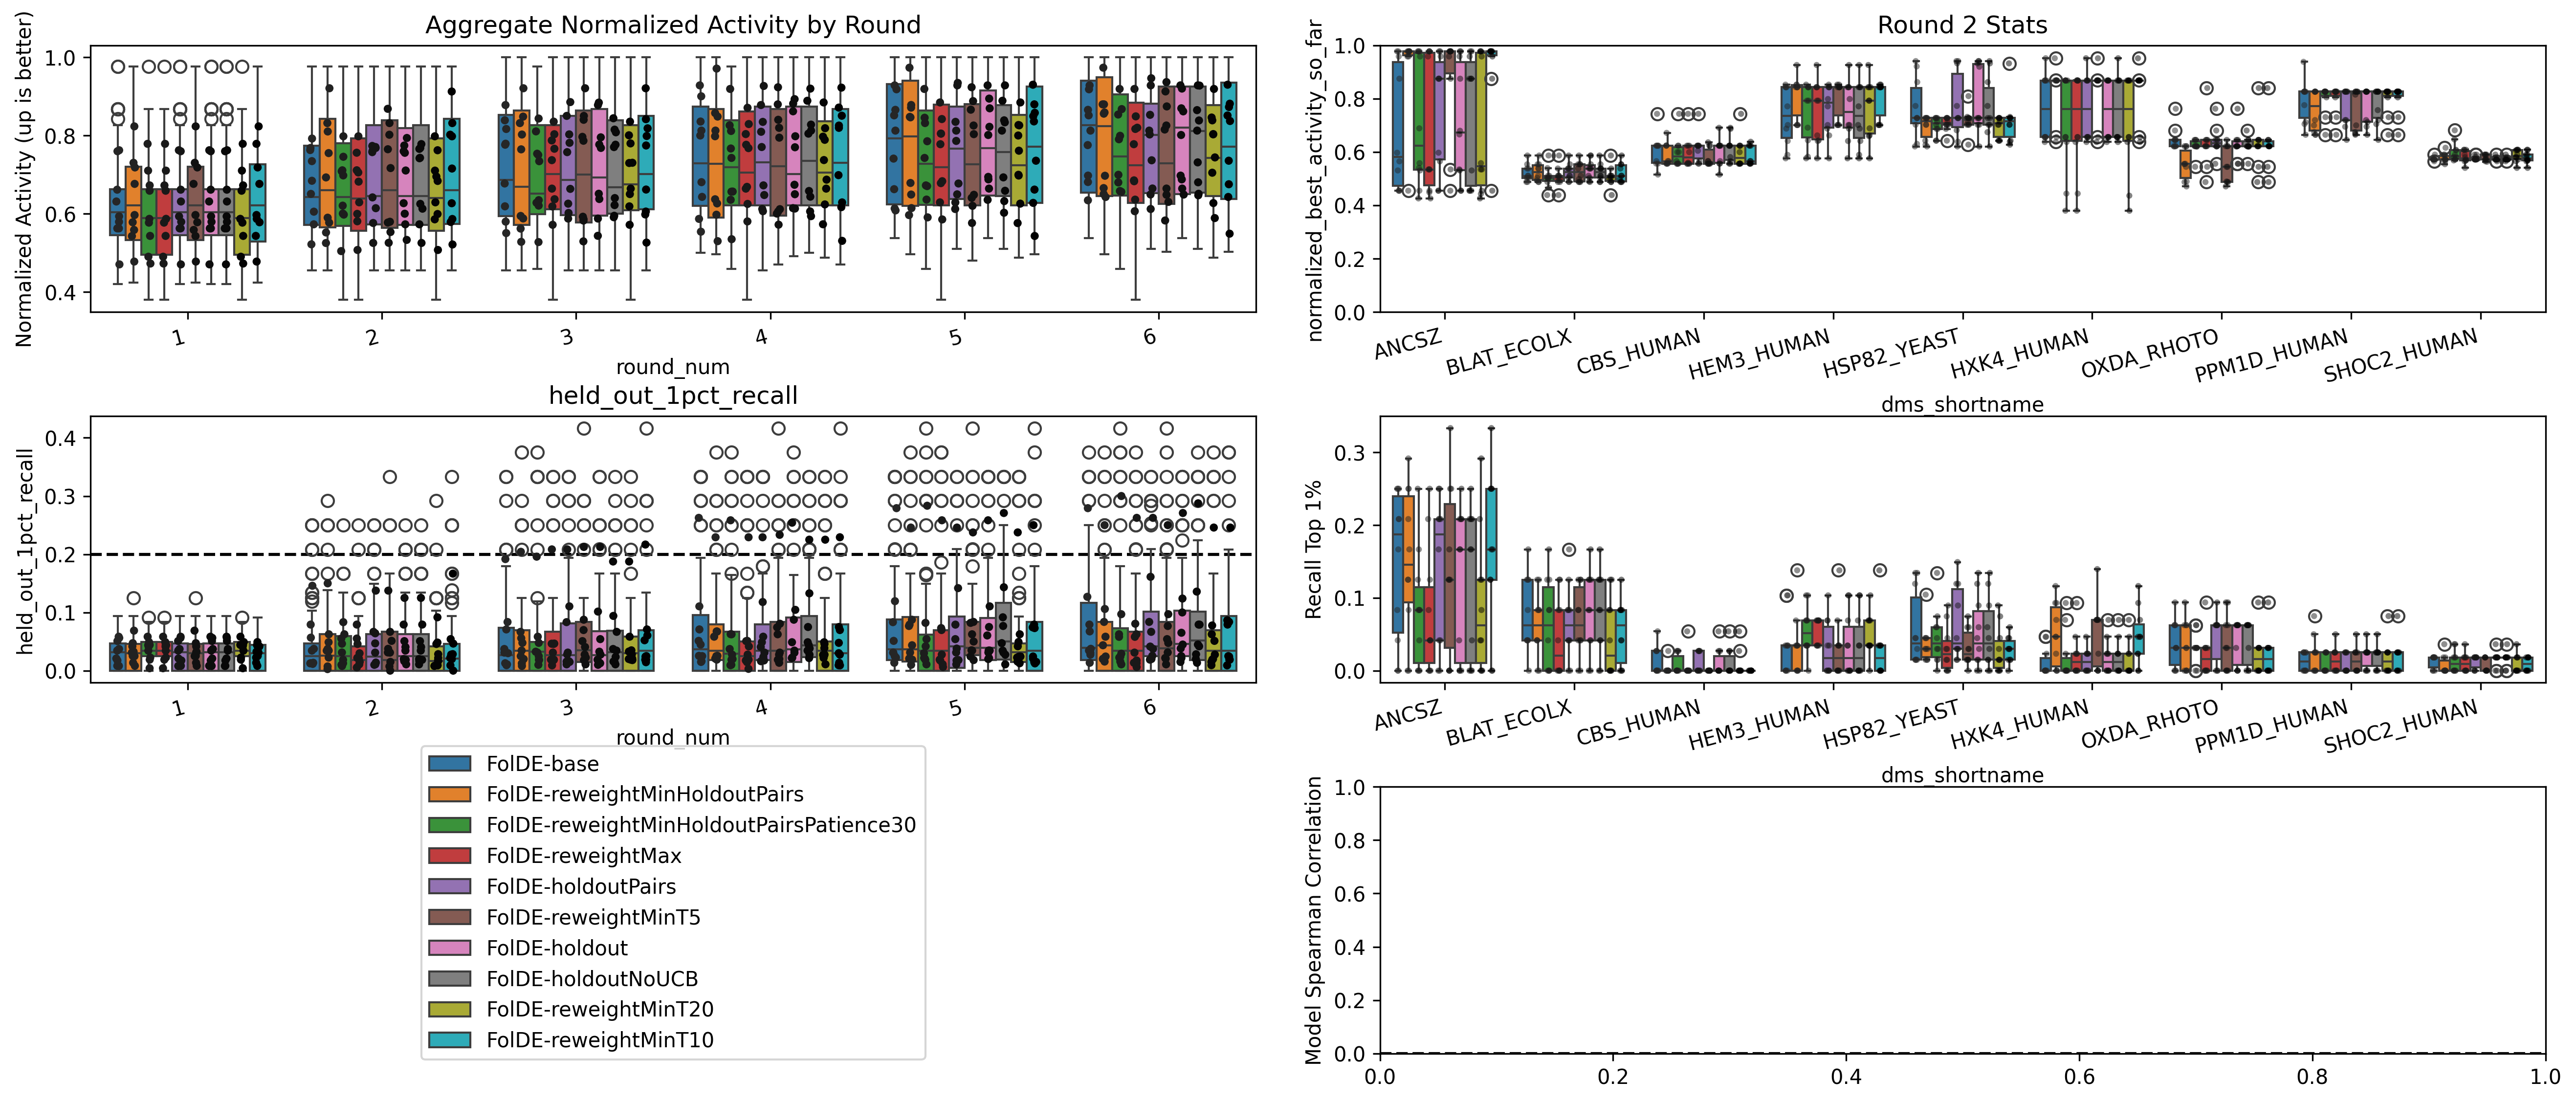

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

import json



DMS_SHORTNAMES = {
    #   'A0A140D2T1_ZIKV_Sourisseau_2019': "A0A140D2T1_ZIKV",
    #   'A0A2Z5U3Z0_9INFA_Doud_2016': "A0A2Z5U3Z0_9INFA",
    #   'ADRB2_HUMAN_Jones_2020': "ADRB2",
    #   'BLAT_ECOLX_Stiffler_2015': "BLAT_ECOLX",
    #   'C6KNH7_9INFA_Lee_2018': "C6KNH7",
    #   'IF1_ECOLI_Kelsic_2016': "IF1_ECOLI",
    #   'MK01_HUMAN_Brenan_2016': "MK01_HUMAN",
    #   'P53_HUMAN_Giacomelli_2018_Null_Etoposide': "P53",
    #   'PHOT_CHLRE_Chen_2023': "PHOT_CHLRE",
    "BLAT_ECOLX_Firnberg_2014": "BLAT_ECOLX",
    "ANCSZ_Hobbs_2022": "ANCSZ",
    "HXK4_HUMAN_Gersing_2022_activity": "HXK4_HUMAN",
    "OXDA_RHOTO_Vanella_2023_activity": "OXDA_RHOTO",
    "SHOC2_HUMAN_Kwon_2022": "SHOC2_HUMAN",
    "ADRB2_HUMAN_Jones_2020": "ADRB2_HUMAN",
    "CBS_HUMAN_Sun_2020": "CBS_HUMAN",
    "P53_HUMAN_Giacomelli_2018_Null_Nutlin": "P53_Null",
    "HSP82_YEAST_Flynn_2019": "HSP82_YEAST",
    "P53_HUMAN_Giacomelli_2018_WT_Nutlin": "P53_WT",
    "MK01_HUMAN_Brenan_2016": "MK01_HUMAN",
    "HEM3_HUMAN_Loggerenberg_2023": "HEM3_HUMAN",
    "PPM1D_HUMAN_Miller_2022": "PPM1D_HUMAN",
}

ROUND = 2


plotting_df = round_metrics_df.copy()
plotting_df["dms_shortname"] = plotting_df.dms_id.apply(lambda x: DMS_SHORTNAMES.get(x))
plotting_df["config_name"] = plotting_df.config_name.apply(
    lambda x: "EvolvePro (ESMC300M)" if x == "EvolvePro" else x
)

plotting_df["inv_best_percentile_so_far"] = plotting_df.best_percentile_so_far.apply(
    lambda x: 1.0 - x
)
single_round_df = plotting_df[plotting_df.round_num == ROUND]


def plot_metric_panel(
    ax,
    df,
    y_column,
    x_column="dms_shortname",
    hue_column="config_name",
    legend=False,
    plot_points=True,
    group_by_campaign=False,
    color_grey=False,
):
    x_order = df[x_column].unique()
    hue_order = df[hue_column].unique()

    # Create boxplot
    extra_args = {}
    if color_grey:
        extra_args["color"] = "#D3D3D3"
    bp = sns.boxplot(
        data=df,
        x=x_column,
        y=y_column,
        hue=hue_column,
        ax=ax,
        legend=legend,
        order=x_order,
        hue_order=hue_order,
        **extra_args,
    )

    if color_grey:
        # Make all box elements light grey
        plt.setp(bp.artists, edgecolor="#D3D3D3")
        plt.setp(bp.lines, color="#D3D3D3")

    if plot_points:
        # Overlay stripplot with black dots
        strip_df = None
        size = None
        alpha = None
        if group_by_campaign:
            strip_df = (
                df.groupby(["dms_shortname", "config_name", "round_num"])[y_column]
                .mean()
                .reset_index()
            )
            size = 4
            alpha = 1
        else:
            strip_df = df
            size = 3
            alpha = 0.5
        sns.stripplot(
            data=strip_df,
            x=x_column,
            y=y_column,
            hue=hue_column,
            dodge=True,
            alpha=alpha,
            ax=ax,
            size=size,
            color="black",
            legend=False,
            order=x_order,
            hue_order=hue_order,
        )

    # Style the plot
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    if legend:
        ax.legend(bbox_to_anchor=(0.5, -0.2), loc="upper center")


# Set up the figure with three subplots

fig = plt.figure(figsize=(18, 8), dpi=300)
gs = gridspec.GridSpec(6, 2, width_ratios=[1, 1])  # 3 rows, 2 columns

# Left column: One plot spanning all 3 rows
left_activity_ax = fig.add_subplot(gs[0:2, 0])
left_bottom_ax = fig.add_subplot(gs[2:4, 0])
ax2 = fig.add_subplot(gs[0:2, 1])
ax3 = fig.add_subplot(gs[2:4, 1])
ax4 = fig.add_subplot(gs[4:6, 1])
fig.tight_layout(pad=3.0)


# Middle panel: best_percentile_so_far
# plot_metric_panel(ax1, plotting_df, 'inv_best_percentile_so_far', x_column='round_num', legend=True)
# ax1.set_title(f'Aggregate Normalized Rank (Round {ROUND})')
# ax1.set_yscale('log')
# ax1.set_ylabel('Normalized Rank (up is better)')
plot_metric_panel(
    left_activity_ax,
    plotting_df,
    "normalized_best_activity_so_far",
    x_column="round_num",
    legend=False,
    group_by_campaign=True,
)
left_activity_ax.set_title(f"Aggregate Normalized Activity by Round")
left_activity_ax.set_ylabel("Normalized Activity (up is better)")

# {'held_out_activity_spearman': -0.014089314320311018,
#  'held_out_1pct_recall': 0.0,
#  'held_out_1pct_auc': 0.5961344295398817,
#  'held_out_10pct_recall': 0.08974358974358974,
#  'held_out_10pct_auc': 0.4942640256776383}
HELD_OUT_STAT = "held_out_1pct_recall" #"held_out_activity_spearman"
# plot_metric_panel(
#     left_bottom_ax,
#     plotting_df,
#     "held_out_10pct_recall",
#     x_column="round_num",
#     legend=False,
#     plot_points=False,
#     color_grey=True,
# )
left_bottom_ax.axhline(0.2, linestyle="--", color="k")
plot_metric_panel(
    left_bottom_ax,
    plotting_df,
    HELD_OUT_STAT,
    x_column="round_num",
    legend=True,
    group_by_campaign=True,
)
left_bottom_ax.set_title(HELD_OUT_STAT)
left_bottom_ax.set_ylabel(HELD_OUT_STAT)

# Top panel: best_activity_so_far
# plot_metric_panel(ax2, single_round_df, 'best_activity_so_far', legend=False)
plot_metric_panel(ax2, single_round_df, "normalized_best_activity_so_far", legend=False)
ax2.set_title(f"Round {ROUND} Stats")
ax2.set_ylim(0, 1)

# Middle panel: best_percentile_so_far
plot_metric_panel(ax3, single_round_df, "held_out_1pct_recall", legend=False)
# ax2.set_ylim(0.95, 1.0)
ax3.set_ylabel("Recall Top 1%")
# ax3.set_yscale("log")
# ax3.set_ylim(ax3.get_ylim()[::-1])  # This flips the axis


# Bottom panel: model_spearman
# plot_metric_panel(ax4, single_round_df, "model_spearman", legend=False)
ax4.set_ylabel(f"Model Spearman Correlation")
ax4.axhline(0.0, linestyle="--", color="k")


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

<Axes: xlabel='round_num', ylabel='held_out_1pct_recall'>

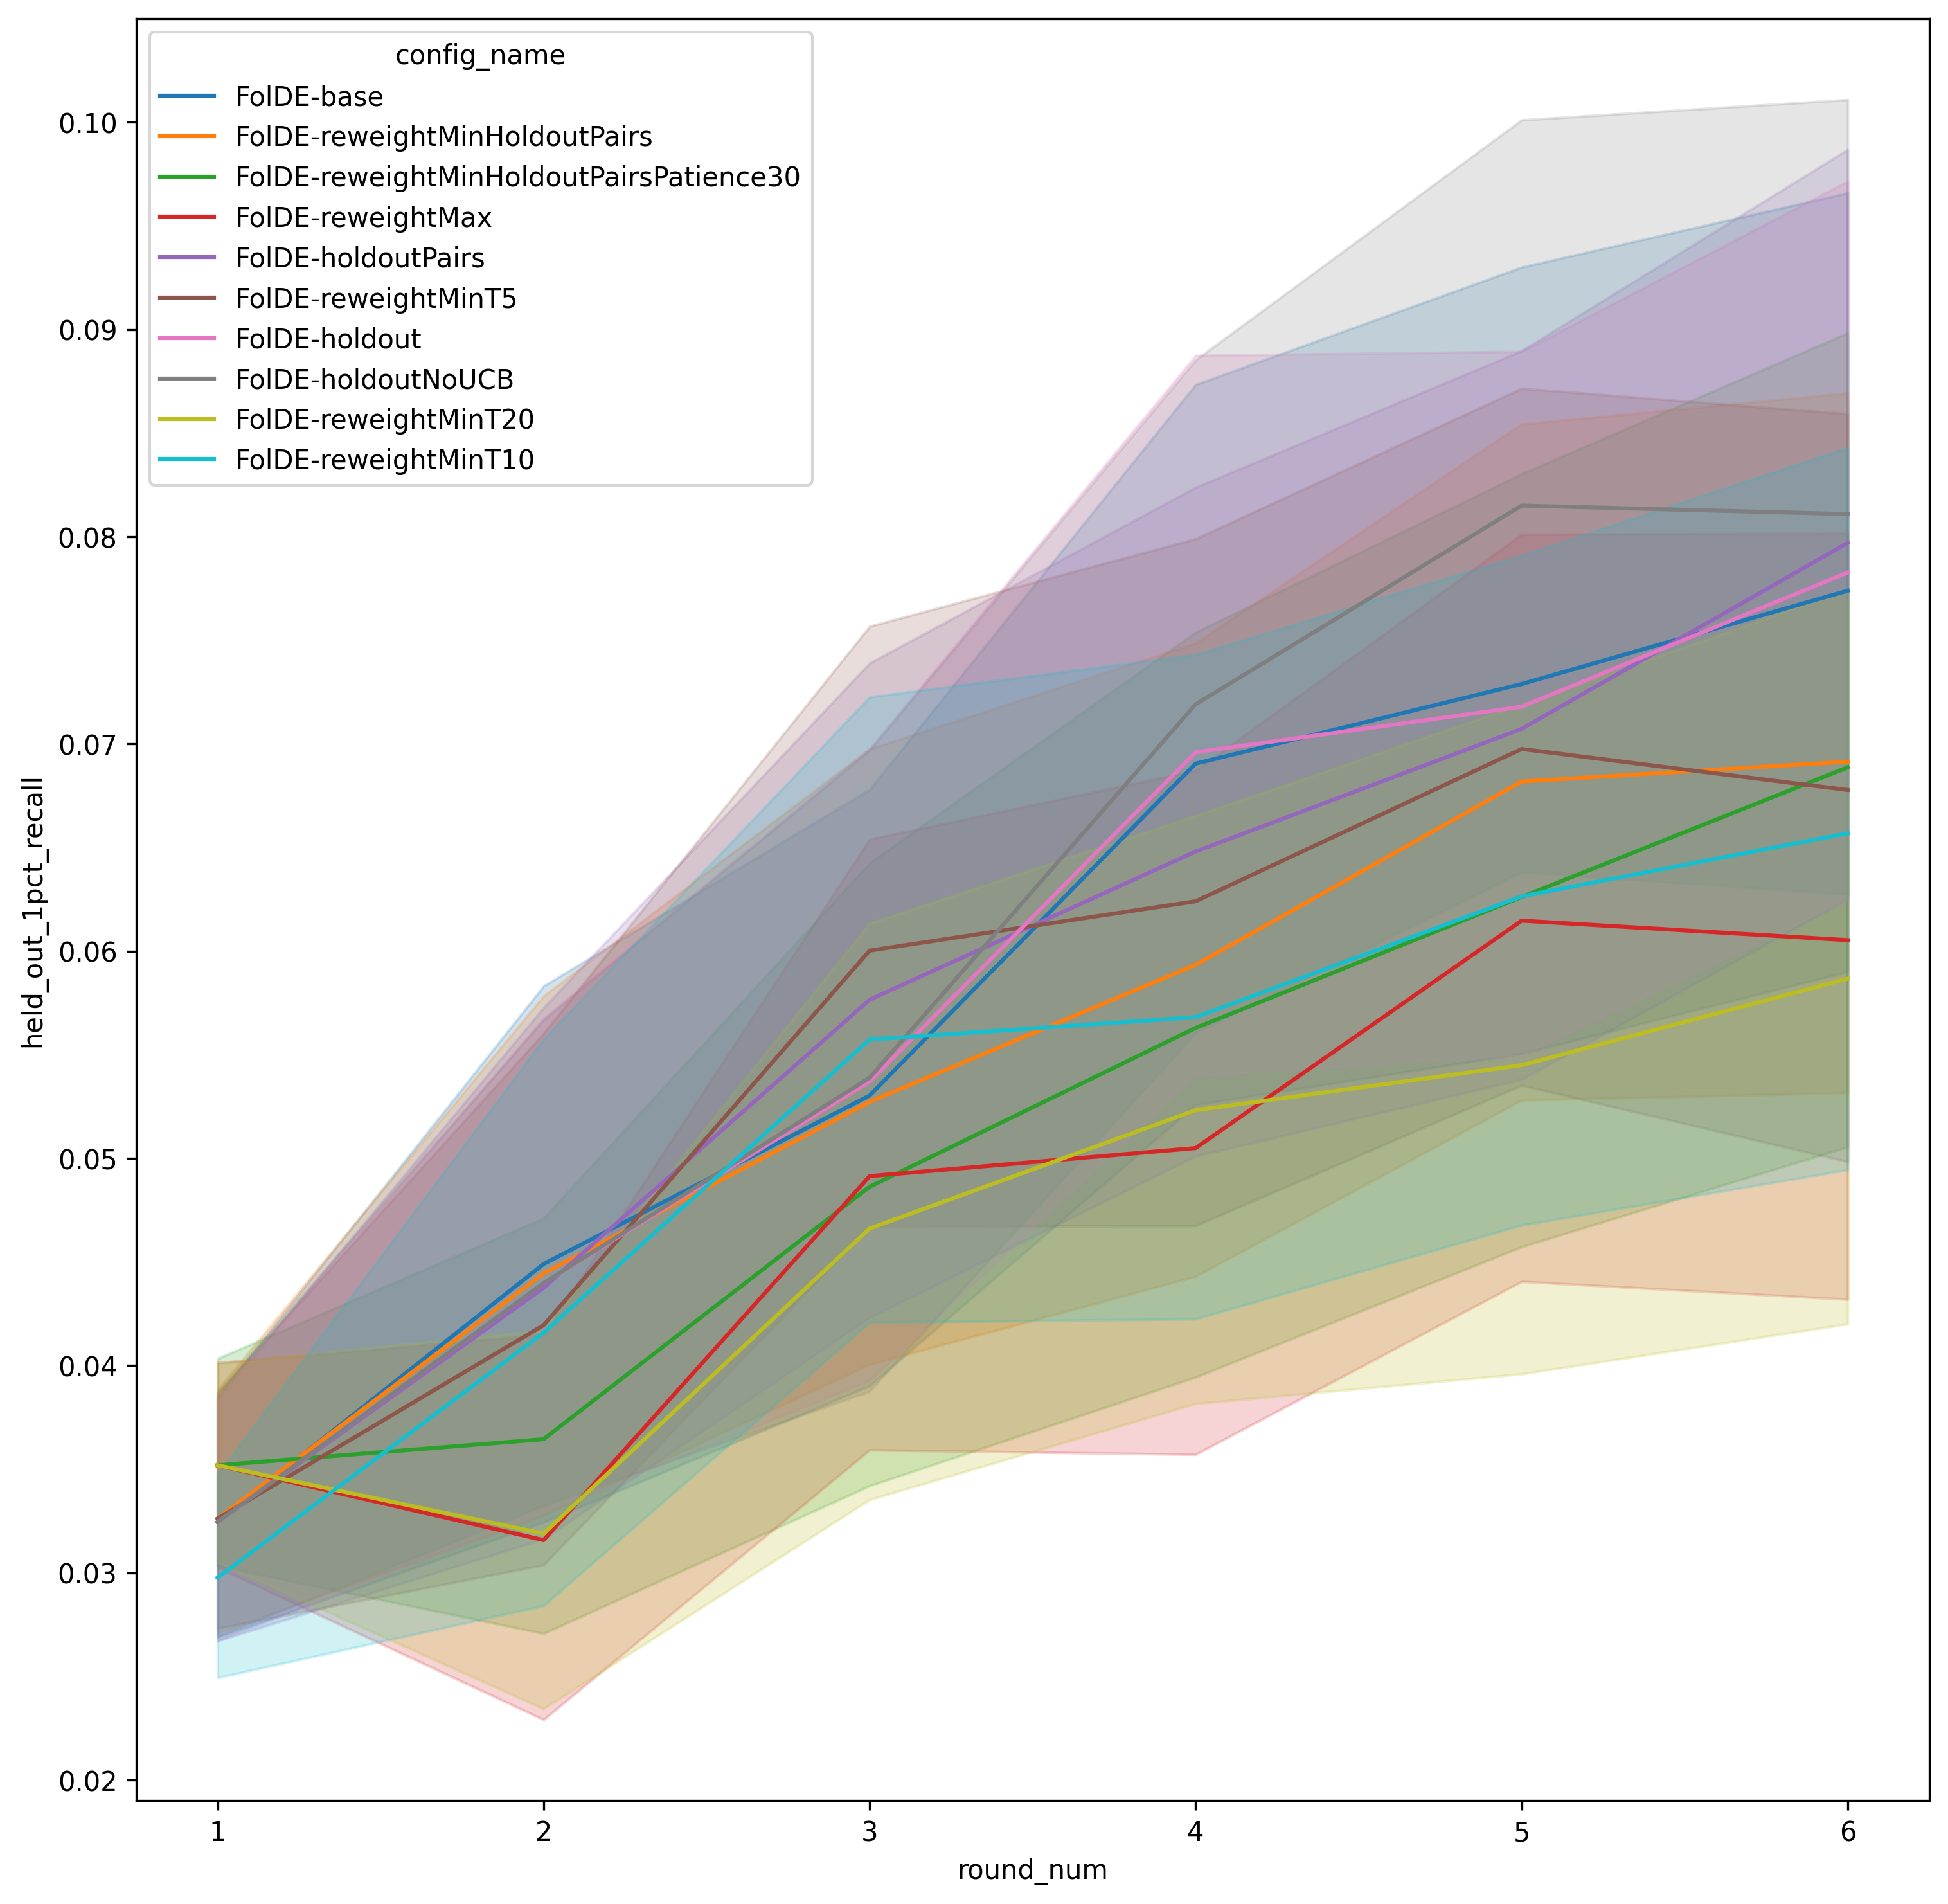

In [3]:
plt.subplots(figsize=(12,12), dpi=300)
sns.lineplot(
    data=round_metrics_df,
    #     (round_metrics_df.dms_id == 'CBS_HUMAN_Sun_2020')
    #     & round_metrics_df.config_name.str.endswith('base')
    # ],
    y='held_out_1pct_recall',
    # y='best_activity_so_far',
    x='round_num',
    hue='config_name',
    # style='config_name',
    # errorbar=None
)
# plt.ylim(0, 0.1)
# round_metrics_df

# Compare Two Methods

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FolDE-base vs. FolDE-reweightMinT5: t-test paired samples, P_val:7.170e-01 t=3.636e-01


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

SHOC2_HUMAN_FolDE-base vs. SHOC2_HUMAN_FolDE-reweightMinT5: t-test paired samples, P_val:1.934e-01 t=1.406e+00
BLAT_ECOLX_FolDE-base vs. BLAT_ECOLX_FolDE-reweightMinT5: t-test paired samples, P_val:6.376e-01 t=4.874e-01
ANCSZ_FolDE-base vs. ANCSZ_FolDE-reweightMinT5: t-test paired samples, P_val:8.911e-01 t=1.408e-01
CBS_HUMAN_FolDE-base vs. CBS_HUMAN_FolDE-reweightMinT5: t-test paired samples, P_val:5.218e-02 t=2.236e+00
HEM3_HUMAN_FolDE-base vs. HEM3_HUMAN_FolDE-reweightMinT5: t-test paired samples, P_val:8.793e-01 t=1.562e-01
HSP82_YEAST_FolDE-base vs. HSP82_YEAST_FolDE-reweightMinT5: t-test paired samples, P_val:1.484e-01 t=1.581e+00
HXK4_HUMAN_FolDE-base vs. HXK4_HUMAN_FolDE-reweightMinT5: t-test paired samples, P_val:3.807e-02 t=-2.429e+00
OXDA_RHOTO_FolDE-base vs. OXDA_RHOTO_FolDE-reweightM

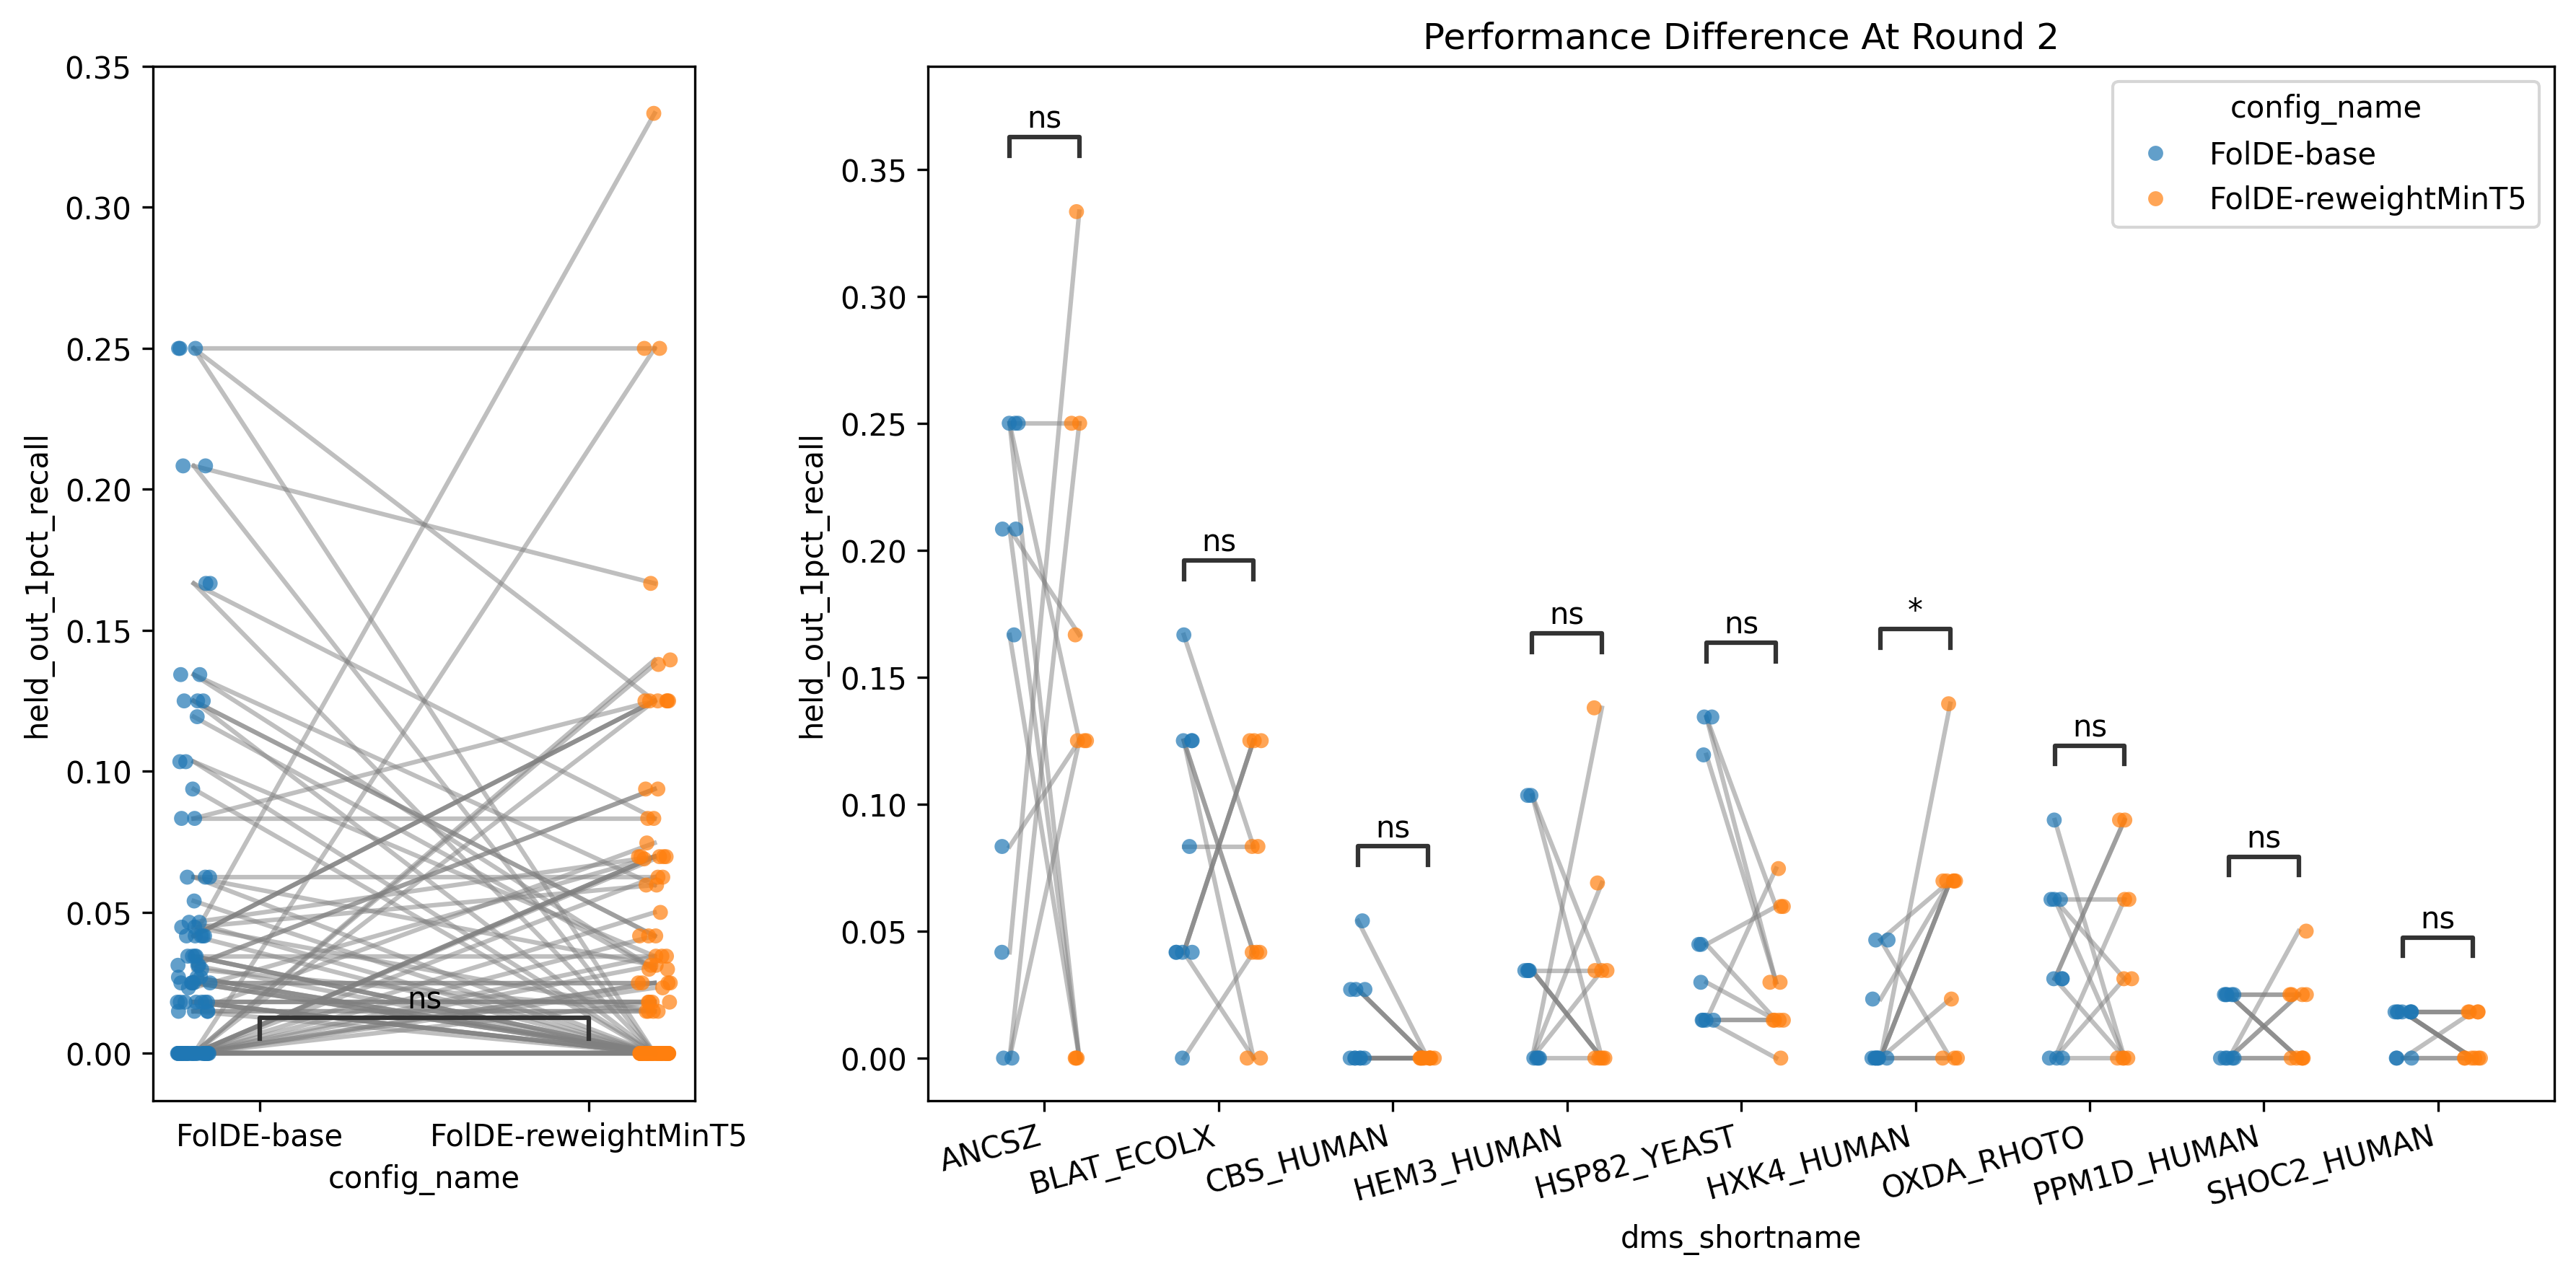

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

method1 = 'FolDE-base'
method2 = 'FolDE-reweightMinT5'

METRIC = 'held_out_1pct_recall'  # 'best_activity_this_round'  # held_out_recall_1pct
ROUND = 2

comparison_df = plotting_df[
    plotting_df.config_name.isin([method1, method2]) & (plotting_df.round_num == ROUND)
].sort_values(['dms_id', 'config_name', 'sim_num'])

# Sort dms_shortname for consistent x-axis order
ordered_dms = sorted(comparison_df['dms_shortname'].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300, width_ratios=(1,3))

sns.stripplot(
    data=comparison_df,
    x="config_name",
    y=METRIC,
    hue="config_name",
    dodge=True,
    jitter=True,
    alpha=0.7,
    order=[method1, method2],
    hue_order=[method1, method2],
    ax=ax1
)
pairs = []
# Connect the two config points for each dms_shortname
pairs.append(
    ((method1, ), (method2, ))
)

for sim_id in comparison_df['sim_num'].unique():
    subset = comparison_df[
        (comparison_df['sim_num'] == sim_id)
    ].set_index('config_name')
    y1 = subset.loc[method1, METRIC]
    y2 = subset.loc[method2, METRIC]
    # Get the x position for this dms_shortname
    # Get the x positions for the two hues (dodge)
    offsets = [-0.2, 0.2]  # adjust if your dodge is different
    ax1.plot(
        [0 + offsets[0], 1 + offsets[1]],
        [y1, y2],
        color='gray',
        alpha=0.5,
        zorder=1
    )

annot1 = Annotator(
    ax1,
    pairs,
    data=comparison_df,
    x='config_name',
    y=METRIC,
    hue="config_name",
    hue_order=[method1, method2]
)
annot1.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
annot1.apply_test()
annot1.annotate()


sns.stripplot(
    data=comparison_df,
    x="dms_shortname",
    y=METRIC,
    hue="config_name",
    dodge=True,
    jitter=True,
    alpha=0.7,
    order=ordered_dms,
    hue_order=[method1, method2],
    ax=ax2
)

pairs = []

# Connect the two config points for each dms_shortname
for dms in ordered_dms:
    pairs.append(
        ((dms, method1), (dms, method2))
    )

    for sim_id in comparison_df['sim_num'].unique():
        subset = comparison_df[
            (comparison_df['dms_shortname'] == dms) &
            (comparison_df['sim_num'] == sim_id)
        ].set_index('config_name')
        y1 = subset.loc[method1, METRIC]
        y2 = subset.loc[method2, METRIC]
        # Get the x position for this dms_shortname
        x_pos = ordered_dms.index(dms)
        # Get the x positions for the two hues (dodge)
        offsets = [-0.2, 0.2]  # adjust if your dodge is different
        ax2.plot(
            [x_pos + offsets[0], x_pos + offsets[1]],
            [y1, y2],
            color='gray',
            alpha=0.5,
            zorder=1
        )

plt.xticks(rotation=15, ha="right")

annot = Annotator(
    ax2,
    pairs,
    data=comparison_df,
    x="dms_shortname",
    y=METRIC,
    hue="config_name",
    comparisons_correction='bonferroni',
    order=ordered_dms,
    hue_order=[method1, method2]
)
annot.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
annot.apply_test()
annot.annotate()

plt.title(f'Performance Difference At Round {ROUND}')
plt.legend(title='config_name')
plt.tight_layout()
plt.show()

In [5]:
comparison_df[
    (comparison_df.round_num == 3)  
    # (comparison_df.dms_shortname == 'BLAT_ECOLX')
].groupby(['config_name', 'dms_id'])['held_out_1pct_recall'].mean()

Series([], Name: held_out_1pct_recall, dtype: float64)

In [6]:
import scipy.stats as stats

# 1. Pivot the DataFrame to get paired values side by side
paired = comparison_df[comparison_df.dms_shortname == 'ANCSZ'].pivot_table(
    index=['dms_id', 'sim_num'],  # or add more columns if needed for unique pairing
    columns='config_name',
    values='held_out_1pct_recall'
)

# 2. Drop any rows with missing values (i.e., where a pair is incomplete)
paired = paired.dropna(subset=[method1, method2])

# 3. Run the paired t-test
t_stat, p_value = stats.ttest_rel(paired[method1], paired[method2])

print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3g}")

Paired t-test: t = 0.141, p = 0.891


/var/tmp/ipykernel_1216940/2395414492.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/var/tmp/ipykernel_1216940/2395414492.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/var/tmp/ipykernel_1216940/2395414492.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


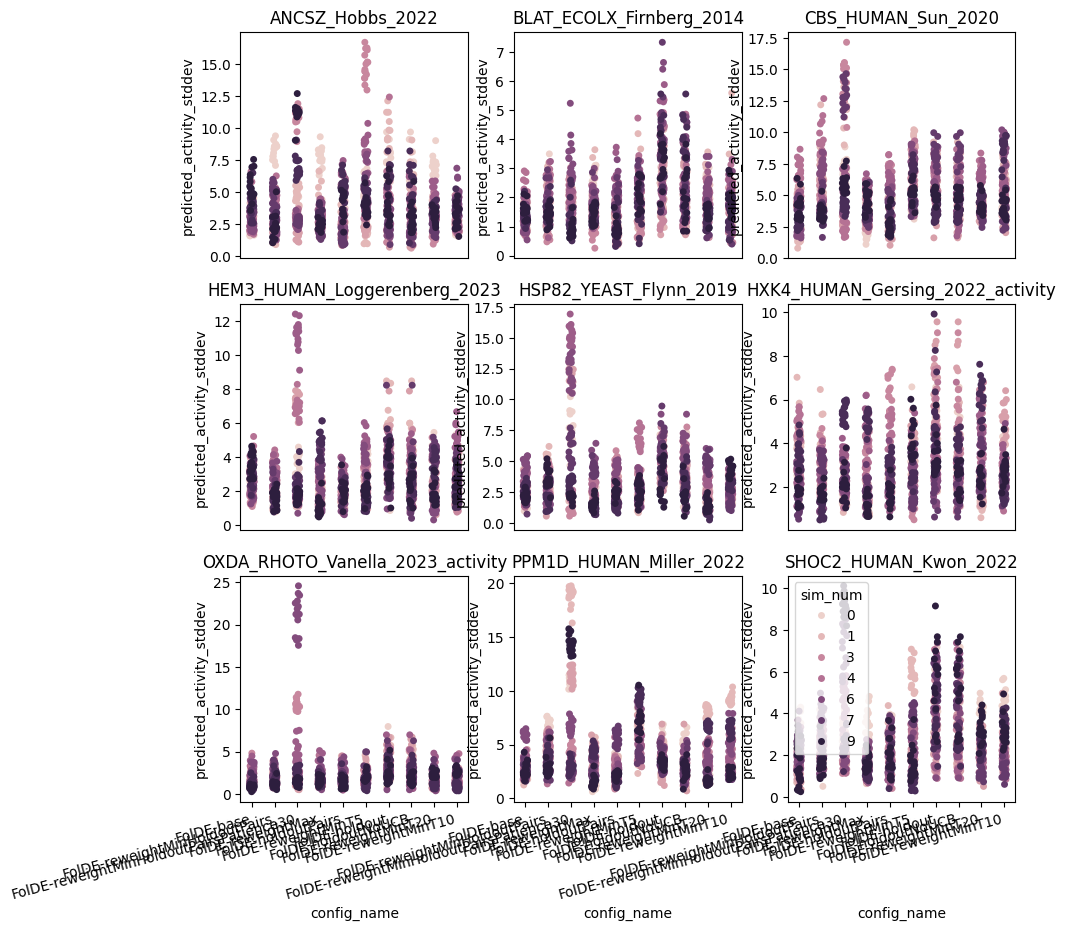

In [7]:
fig, axs = plt.subplots(3, 3, figsize=(10,10))
axs = axs.flatten()

for ii, (dms_id, ax) in enumerate(zip(mutant_df.dms_id.unique(), axs)):
    sns.stripplot(
        data=mutant_df[
            (mutant_df.dms_id == dms_id) &
            (mutant_df.round_found == 2)
        ],
        x='config_name',
        y='predicted_activity_stddev',
        ax=ax,
        hue='sim_num'
    )
    if ii > 5:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    else:
        ax.set_xticks([])
        ax.set_xlabel('')

    ax.set_title(dms_id)
    if ii != 8:
        ax.get_legend().remove()

<Axes: xlabel='predicted_activity_stddev', ylabel='activity'>

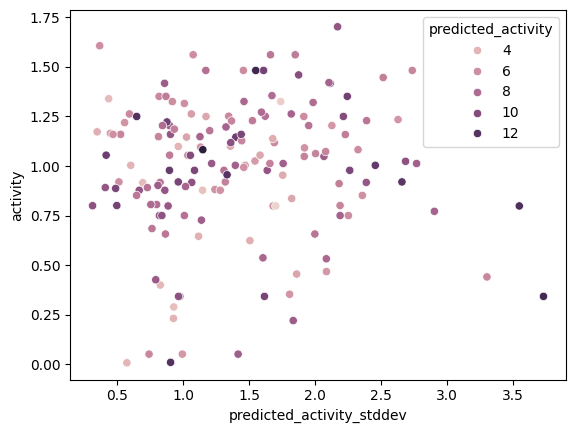

In [8]:

sns.scatterplot(
    data=mutant_df[
        (mutant_df.round_found == 2) &
        (mutant_df.dms_id == 'BLAT_ECOLX_Firnberg_2014') &
        (mutant_df.config_name == 'FolDE-holdoutPairs')
    ],
    x='predicted_activity_stddev',
    y='activity',
    hue='predicted_activity'
)

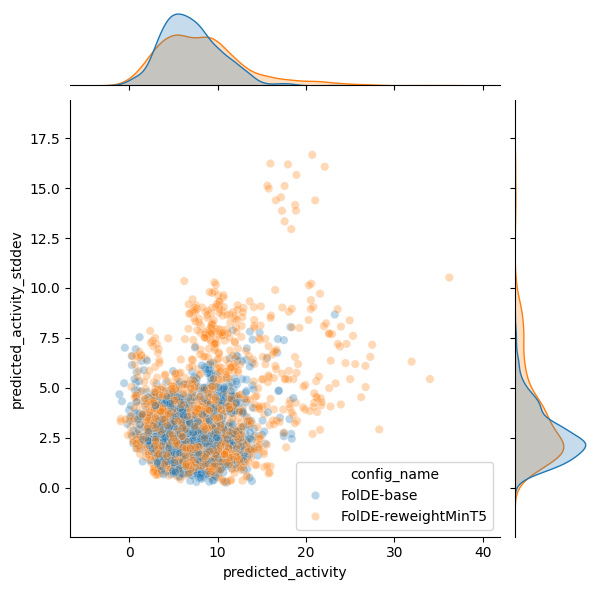

In [9]:
sns.jointplot(
    data=mutant_df[
        (mutant_df.round_found == 2) &
        # (mutant_df.dms_id == 'ANCSZ_Hobbs_2022') &
        (mutant_df.config_name.isin(['FolDE-base', 'FolDE-reweightMinT5']))
    ],
    x='predicted_activity',
    y='predicted_activity_stddev',
    hue='config_name',
    alpha=0.3
)

# Plot Training Losses

In [29]:
train_df

,loss_type,log_step,loss,model_idx,sim_idx,dms_id,config_name,epoch,dms_shortname
0,pretrain_train,0,0.572165,0,0,ANCSZ_Hobbs_2022,FolDE-base,0,ANCSZ
1,pretrain_train,1,0.344472,0,0,ANCSZ_Hobbs_2022,FolDE-base,10,ANCSZ
2,pretrain_train,2,0.276469,0,0,ANCSZ_Hobbs_2022,FolDE-base,20,ANCSZ
3,pretrain_train,3,0.222421,0,0,ANCSZ_Hobbs_2022,FolDE-base,30,ANCSZ
4,pretrain_train,4,0.195139,0,0,ANCSZ_Hobbs_2022,FolDE-base,40,ANCSZ
...,...,...,...,...,...,...,...,...,...
80,finetune_recall_1pct,16,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,160,SHOC2_HUMAN
81,finetune_recall_1pct,17,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,170,SHOC2_HUMAN
82,finetune_recall_1pct,18,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,180,SHOC2_HUMAN
83,finetune_recall_1pct,19,0.018182,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,190,SHOC2_HUMAN


ANCSZ
BLAT_ECOLX
CBS_HUMAN
HEM3_HUMAN
HSP82_YEAST
HXK4_HUMAN
OXDA_RHOTO
PPM1D_HUMAN
SHOC2_HUMAN


Text(0.5, 0.98, 'Loss for FolDE-holdoutPairs, Round 2')

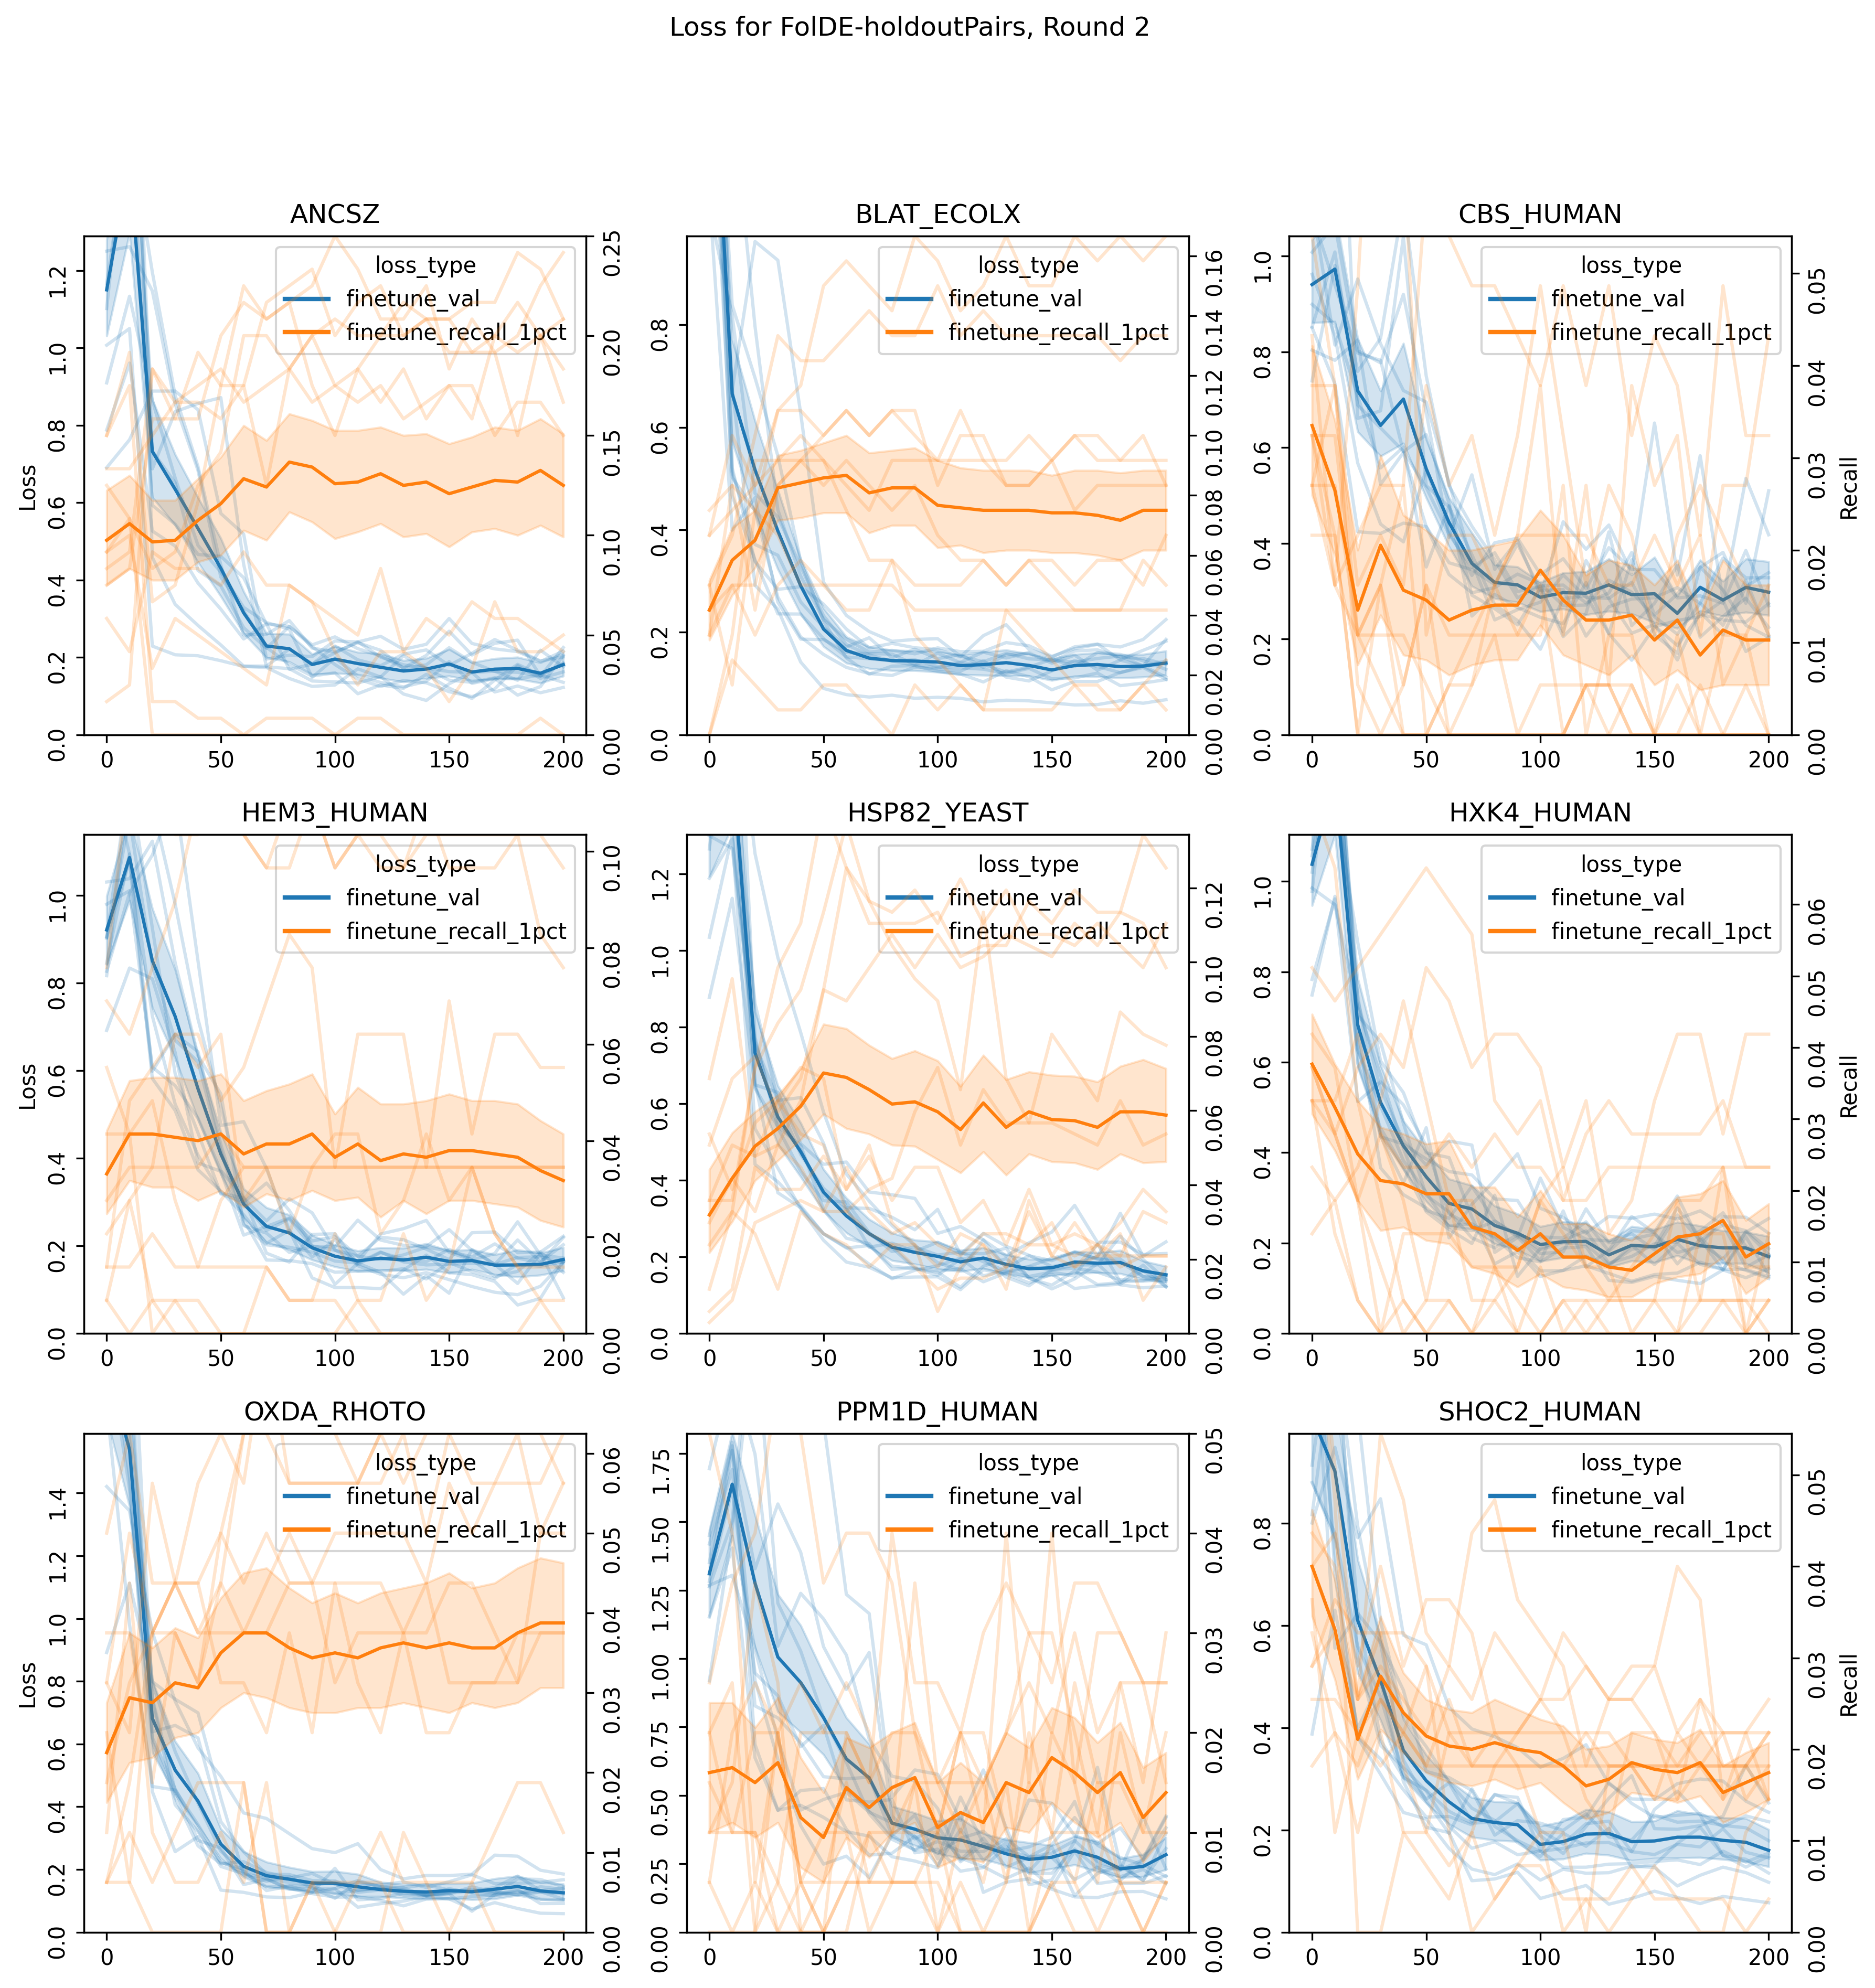

In [71]:
from folde.util import get_training_loss_df
import matplotlib.pyplot as plt

CONFIG_NAME = 'FolDE-holdoutPairs'
ROUND = 1

train_df = get_training_loss_df(results, ROUND)
train_df['epoch'] = train_df['log_step'] * results.campaign_results[0].config_results[0].config.few_shot_model_params['val_frequency']
train_df['dms_shortname'] = train_df['dms_id'].apply(lambda x: DMS_SHORTNAMES.get(x))

fig, axs = plt.subplots(3, 3, figsize=(14, 14), dpi=300)
axs = axs.flatten()
for ax_idx, (dms_shortname, ax) in enumerate(zip(train_df['dms_shortname'].unique(), axs)):
    print(dms_shortname)
    plot_df = train_df[
        (train_df.dms_shortname == dms_shortname) &
        (train_df.config_name == CONFIG_NAME) &
        # (train_df.loss_type.str.startswith('pretrain'))
        (train_df.loss_type.str.startswith('finetune_recall') | train_df.loss_type.str.startswith('finetune_val'))
    ]

    # Get unique loss_types and assign a color to each
    loss_types = plot_df['loss_type'].unique()
    color_map = {lt: color for lt, color in zip(loss_types, plt.cm.tab10.colors)}
    sim_idx_to_alpha_map = {}

    right_ax = ax.twinx()

    for sub_ax, plot_subset in [
        (ax, plot_df[~plot_df.loss_type.str.startswith('finetune_recall')]),
        (right_ax, plot_df[plot_df.loss_type.str.startswith('finetune_recall')]),
    ]:
        # Group by sim_idx and model_idx, but color by loss_type
        for sim_idx in plot_subset.sim_idx.unique():
            sim_plot_df = plot_subset[plot_subset.sim_idx == sim_idx].groupby(['epoch', 'loss_type']).loss.mean().reset_index()
            sns.lineplot(
                ax=sub_ax,
                data=sim_plot_df,
                y='loss',
                x='epoch',
                hue='loss_type',
                palette=color_map,
                alpha=0.2,
                errorbar=None,
                legend=False
            )

        # for (sim_idx, model_idx, loss_type), group in plot_df.groupby(['sim_idx', 'model_idx', 'loss_type']):
        #     # loss_type = group['loss_type'].iloc[0]
        #     color = color_map[loss_type]
        #     alpha = sim_idx_to_alpha_map.get(sim_idx, 0.1)
        #     sub_ax.plot(group['epoch'], group['loss'], color=color, alpha=alpha)  # alpha for visibility
        
        sns.lineplot(
            ax=sub_ax,
            data=plot_subset,
            x='epoch',
            y='loss',
            hue='loss_type',
            palette=color_map,
            legend=False
        )
        try:
            sub_ax.set_ylim(0.0, plot_subset.loss.dropna().quantile(0.95))
        except Exception as e:
            print(plot_subset.loss.dropna().quantile(0.95))
            print(plot_subset.loss.dropna().mean())
            print(plot_subset.loss.dropna().describe())
            print(e)
        sub_ax.tick_params(axis='y', labelrotation=90)
    ax.set_ylabel('Loss' if ax_idx % 3 == 0 else '')
    right_ax.set_ylabel('Recall' if ax_idx % 3 == 2 else '')


    # Optionally, add a legend for loss_type
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=color_map[lt], lw=2, label=lt) for lt in loss_types]
    ax.legend(handles=legend_elements, title='loss_type')

    dms_name = '_'.join(plot_df['dms_shortname'].unique())
    config_name = '_'.join(plot_df['config_name'].unique())
    ax.set_title(f'{dms_name}')

    ax.set_xlabel('')
    # ax.set_ylim(0, 1.0)
fig.suptitle(f'Loss for {CONFIG_NAME}, Round {ROUND+1}')


<Axes: xlabel='finetune_val', ylabel='finetune_recall_1pct'>

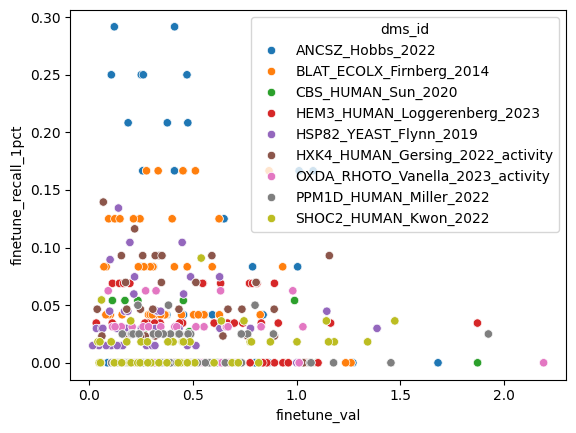

In [91]:

pivoted = train_df[train_df.epoch == 200].pivot_table(
    index=['dms_id', 'config_name', 'model_idx', 'sim_idx'],
    columns='loss_type',
    values='loss',
).reset_index()

sns.scatterplot(
    data=pivoted,
    # data=pivoted[pivoted.dms_id == 'PPM1D_HUMAN_Miller_2022'],
    x='finetune_val',
    y='finetune_recall_1pct',
    hue='dms_id'
)

In [80]:
train_df

,loss_type,log_step,loss,model_idx,sim_idx,dms_id,config_name,epoch,dms_shortname
0,pretrain_train,0,0.574605,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,0,ANCSZ
1,pretrain_train,1,0.276604,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,10,ANCSZ
2,pretrain_train,2,0.192737,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,20,ANCSZ
3,pretrain_train,3,0.161864,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,30,ANCSZ
4,pretrain_train,4,0.136241,0,0,ANCSZ_Hobbs_2022,FolDE-holdout,40,ANCSZ
...,...,...,...,...,...,...,...,...,...
66,finetune_recall_1pct,16,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,160,SHOC2_HUMAN
67,finetune_recall_1pct,17,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,170,SHOC2_HUMAN
68,finetune_recall_1pct,18,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,180,SHOC2_HUMAN
69,finetune_recall_1pct,19,0.000000,4,9,SHOC2_HUMAN_Kwon_2022,FolDE-holdoutNoUCB,190,SHOC2_HUMAN


In [6]:
train_df[train_df.loss_type == 'finetune_val']

,loss_type,epoch,loss,model_idx,sim_idx,dms_id,config_name,dms_shortname
31,finetune_val,0,0.002490,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
32,finetune_val,10,0.045162,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
33,finetune_val,20,0.014941,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
34,finetune_val,30,0.010580,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
35,finetune_val,40,0.008220,0,0,ANCSZ_Hobbs_2022,FolDE_importance_sampling,ANCSZ
...,...,...,...,...,...,...,...,...
49,finetune_val,160,1.531329,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
50,finetune_val,170,1.528102,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
51,finetune_val,180,1.345432,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
52,finetune_val,190,1.330641,4,9,SHOC2_HUMAN_Kwon_2022,FolDE_base,SHOC2_HUMAN
